In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load dataset
df = pd.read_csv('clusteringmidterm.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nDescriptive statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())


Dataset shape: (8950, 18)

First 5 rows:
  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.08333

In [4]:
def preprocess_data(df):
    """
    Clean dan preprocessing data customer
    """
    df_clean = df.copy()

    # Simpan CUST_ID lalu drop untuk clustering
    cust_ids = df_clean['CUST_ID']
    df_clean = df_clean.drop('CUST_ID', axis=1)

    # Cek missing values
    print("Missing values before imputation:")
    print(df_clean.isnull().sum())

    # Imputasi median
    for col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    # IQR capping outlier
    def cap_outliers(series):
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        return series.clip(lower, upper)

    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        df_clean[col] = cap_outliers(df_clean[col])

    # Feature engineering
    df_clean['TOTAL_PURCHASES'] = df_clean['ONEOFF_PURCHASES'] + df_clean['INSTALLMENTS_PURCHASES']
    df_clean['PURCHASE_TO_BALANCE_RATIO'] = df_clean['PURCHASES'] / (df_clean['BALANCE'] + 1)
    df_clean['CASH_ADVANCE_TO_LIMIT_RATIO'] = df_clean['CASH_ADVANCE'] / (df_clean['CREDIT_LIMIT'] + 1)
    df_clean['PAYMENT_TO_MINPAYMENT_RATIO'] = df_clean['PAYMENTS'] / (df_clean['MINIMUM_PAYMENTS'] + 1)
    df_clean['UTILIZATION_RATE'] = df_clean['BALANCE'] / (df_clean['CREDIT_LIMIT'] + 1)

    # Scaling
    scaler = RobustScaler()
    scaled_data = scaler.fit_transform(df_clean)

    print(f"\nProcessed data shape: {scaled_data.shape}")
    return scaled_data, df_clean, cust_ids, scaler


# Apply preprocessing
scaled_data, df_clean, cust_ids, scaler = preprocess_data(df)


Missing values before imputation:
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Processed data shape: (8950, 22)


Explained variance ratio: [0.64501238 0.21650893]
Total explained variance: 86.15%


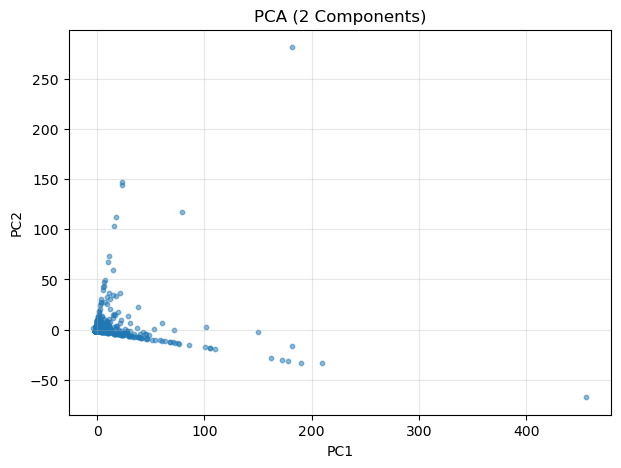

In [5]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print(f"Total explained variance: {pca.explained_variance_ratio_.sum()*100:.2f}%")

plt.figure(figsize=(7, 5))
plt.scatter(pca_data[:, 0], pca_data[:, 1], s=10, alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (2 Components)')
plt.grid(True, alpha=0.3)
plt.show()


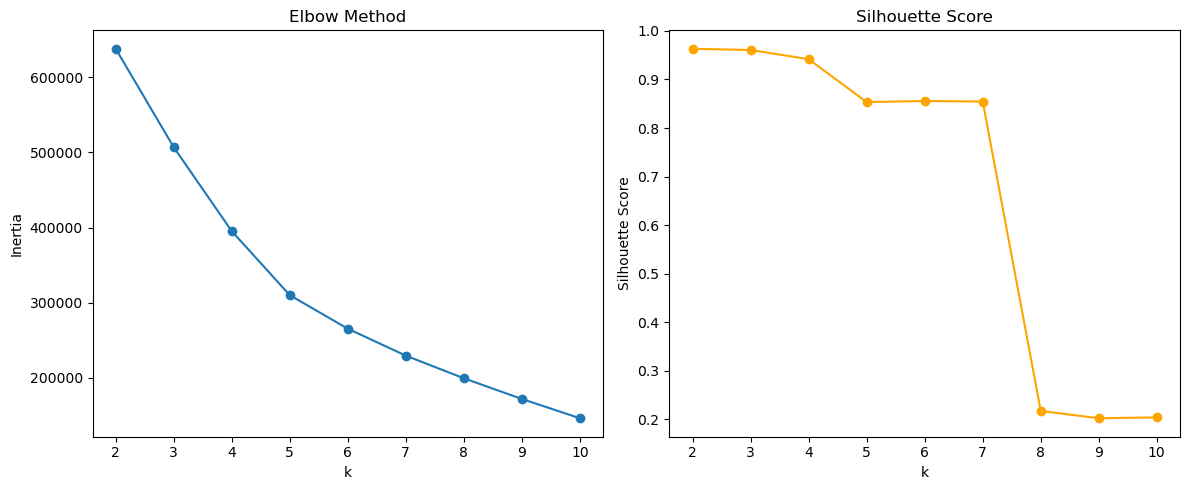

Optimal k (by silhouette): 2


In [6]:
def find_optimal_clusters(data, k_min=2, k_max=10):
    inertias = []
    silhouettes = []
    Ks = range(k_min, k_max+1)

    for k in Ks:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = kmeans.fit_predict(data)
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(data, labels))

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].plot(Ks, inertias, marker='o')
    ax[0].set_xlabel('k')
    ax[0].set_ylabel('Inertia')
    ax[0].set_title('Elbow Method')

    ax[1].plot(Ks, silhouettes, marker='o', color='orange')
    ax[1].set_xlabel('k')
    ax[1].set_ylabel('Silhouette Score')
    ax[1].set_title('Silhouette Score')

    plt.tight_layout()
    plt.show()

    optimal_k = Ks[int(np.argmax(silhouettes))]
    print(f"Optimal k (by silhouette): {optimal_k}")
    return optimal_k


optimal_k = find_optimal_clusters(scaled_data, k_min=2, k_max=10)


In [7]:
def apply_clustering(data, n_clusters=4):
    results = {}

    # K-Means
    print("\n" + "="*50)
    print("K-MEANS CLUSTERING")
    print("="*50)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    kmeans_labels = kmeans.fit_predict(data)
    results['kmeans'] = {
        'labels': kmeans_labels,
        'model': kmeans,
        'inertia': kmeans.inertia_
    }

    # Hierarchical
    print("\n" + "="*50)
    print("HIERARCHICAL CLUSTERING")
    print("="*50)
    hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
    hierarchical_labels = hierarchical.fit_predict(data)
    results['hierarchical'] = {
        'labels': hierarchical_labels,
        'model': hierarchical
    }

    # DBSCAN
    print("\n" + "="*50)
    print("DBSCAN CLUSTERING")
    print("="*50)
    dbscan = DBSCAN(eps=0.5, min_samples=10)
    dbscan_labels = dbscan.fit_predict(data)
    results['dbscan'] = {
        'labels': dbscan_labels,
        'model': dbscan
    }

    # Evaluasi
    for method in ['kmeans', 'hierarchical']:
        labels = results[method]['labels']
        if len(set(labels)) > 1:
            sil = silhouette_score(data, labels)
            dbi = davies_bouldin_score(data, labels)
            print(f"\n{method.upper()} Evaluation:")
            print(f"Silhouette Score: {sil:.3f}")
            print(f"Davies-Bouldin Index: {dbi:.3f}")

    # Info DBSCAN
    n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    print(f"\nDBSCAN found {n_clusters_dbscan} clusters")
    print(f"Noise points: {list(dbscan_labels).count(-1)}")

    return results


clustering_results = apply_clustering(scaled_data, n_clusters=optimal_k)



K-MEANS CLUSTERING

HIERARCHICAL CLUSTERING

DBSCAN CLUSTERING

KMEANS Evaluation:
Silhouette Score: 0.963
Davies-Bouldin Index: 0.504

HIERARCHICAL Evaluation:
Silhouette Score: 0.969
Davies-Bouldin Index: 0.313

DBSCAN found 12 clusters
Noise points: 7981


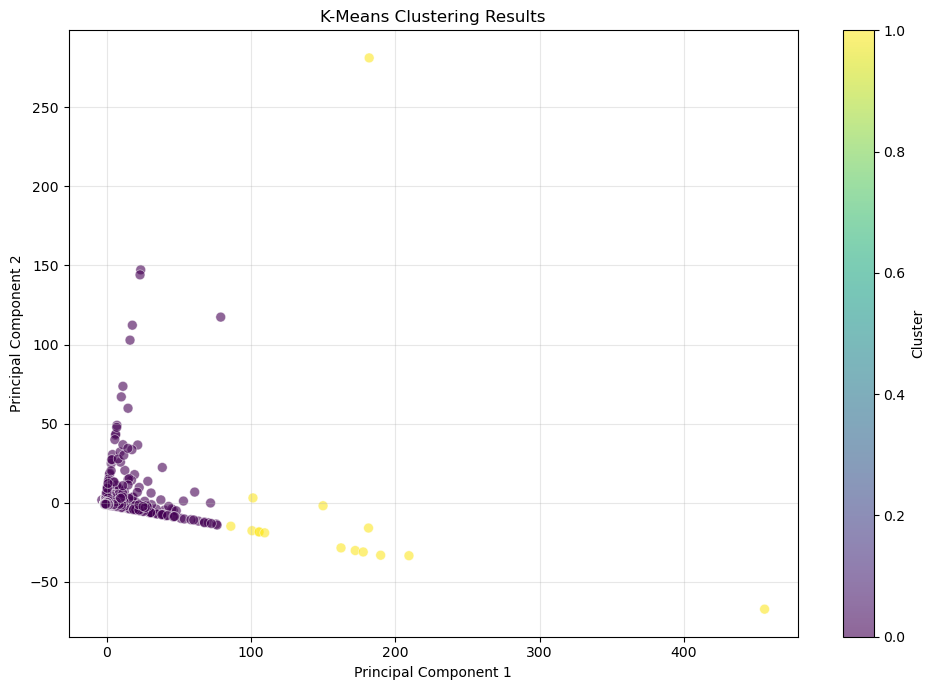


Cluster distribution for K-Means:
Cluster 0: 8935 customers (99.8%)
Cluster 1: 15 customers (0.2%)


In [8]:
def visualize_clusters(data, labels, algorithm_name):
    pca_2d = PCA(n_components=2)
    data_2d = pca_2d.fit_transform(data)

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        data_2d[:, 0], data_2d[:, 1],
        c=labels, cmap='viridis', alpha=0.6,
        s=50, edgecolors='w', linewidth=0.5
    )
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(f'{algorithm_name} Clustering Results')
    plt.colorbar(scatter, label='Cluster')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    unique, counts = np.unique(labels, return_counts=True)
    print(f"\nCluster distribution for {algorithm_name}:")
    for c, cnt in zip(unique, counts):
        print(f"Cluster {c}: {cnt} customers ({cnt/len(labels)*100:.1f}%)")


visualize_clusters(scaled_data, clustering_results['kmeans']['labels'], 'K-Means')


In [9]:
def interpret_clusters(df_original, labels, n_clusters):
    df_analysis = df_original.copy()
    df_analysis['CLUSTER'] = labels

    cluster_profiles = {}
    key_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE',
                    'CREDIT_LIMIT', 'PAYMENTS', 'TENURE']

    print("\n" + "="*60)
    print("CLUSTER INTERPRETATIONS")
    print("="*60)

    for cluster in range(n_clusters):
        cluster_data = df_analysis[df_analysis['CLUSTER'] == cluster]

        profile = {
            'size': len(cluster_data),
            'percentage': len(cluster_data) / len(df_analysis) * 100,
            'characteristics': {}
        }

        for feat in key_features:
            profile['characteristics'][feat] = {
                'mean': cluster_data[feat].mean(),
                'median': cluster_data[feat].median(),
                'std': cluster_data[feat].std()
            }

        cluster_profiles[cluster] = profile

        balance_mean = profile['characteristics']['BALANCE']['mean']
        purchases_mean = profile['characteristics']['PURCHASES']['mean']
        cash_adv_mean = profile['characteristics']['CASH_ADVANCE']['mean']
        credit_limit = profile['characteristics']['CREDIT_LIMIT']['mean']
        payments = profile['characteristics']['PAYMENTS']['mean']

        print(f"\nCLUSTER {cluster} - {profile['size']} customers ({profile['percentage']:.1f}%)")
        print("-"*40)

        if purchases_mean > df_analysis['PURCHASES'].mean() and balance_mean < df_analysis['BALANCE'].mean():
            ctype = "High Spenders / Good Payer"
            desc = "Sering belanja tapi balance rendah, cenderung bayar penuh."
        elif cash_adv_mean > df_analysis['CASH_ADVANCE'].mean():
            ctype = "Cash Advance Users"
            desc = "Sering menggunakan cash advance, indikasi tekanan finansial."
        elif balance_mean > df_analysis['BALANCE'].mean() * 1.5:
            ctype = "High Balance / Risky"
            desc = "Balance tinggi, risiko kredit lebih besar."
        elif purchases_mean < df_analysis['PURCHASES'].mean() * 0.5:
            ctype = "Low Activity / Inactive"
            desc = "Jarang memakai kartu, aktivitas rendah."
        else:
            ctype = "Average Users"
            desc = "Penggunaan moderat, user rata-rata."

        print(f"Type: {ctype}")
        print(f"Description: {desc}")

        print("\nKey Statistics (mean):")
        print(f" • Balance: {balance_mean:,.0f}")
        print(f" • Purchases: {purchases_mean:,.0f}")
        print(f" • Cash Advances: {cash_adv_mean:,.0f}")
        print(f" • Credit Limit: {credit_limit:,.0f}")
        print(f" • Payments: {payments:,.0f}")

        utilization = balance_mean / credit_limit if credit_limit > 0 else 0
        print("\nDerived Metrics:")
        print(f" • Credit Utilization: {utilization:.1%}")
        print(f" • Purchase to Balance Ratio: {purchases_mean / (balance_mean + 1):.2f}")

    return df_analysis, cluster_profiles


df_labeled, cluster_profiles = interpret_clusters(
    df_clean,
    clustering_results['kmeans']['labels'],
    optimal_k
)



CLUSTER INTERPRETATIONS

CLUSTER 0 - 8935 customers (99.8%)
----------------------------------------
Type: Cash Advance Users
Description: Sering menggunakan cash advance, indikasi tekanan finansial.

Key Statistics (mean):
 • Balance: 1,393
 • Purchases: 737
 • Cash Advances: 674
 • Credit Limit: 4,421
 • Payments: 1,348

Derived Metrics:
 • Credit Utilization: 31.5%
 • Purchase to Balance Ratio: 0.53

CLUSTER 1 - 15 customers (0.2%)
----------------------------------------
Type: High Spenders / Good Payer
Description: Sering belanja tapi balance rendah, cenderung bayar penuh.

Key Statistics (mean):
 • Balance: 0
 • Purchases: 1,078
 • Cash Advances: 0
 • Credit Limit: 3,487
 • Payments: 1,096

Derived Metrics:
 • Credit Utilization: 0.0%
 • Purchase to Balance Ratio: 886.83


CUSTOMER CLUSTERING PIPELINE

1) LOADING & PREPROCESSING...
Missing values before imputation:
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Processed data shape: (8950, 22)

2) FINDING OPTIMAL K...


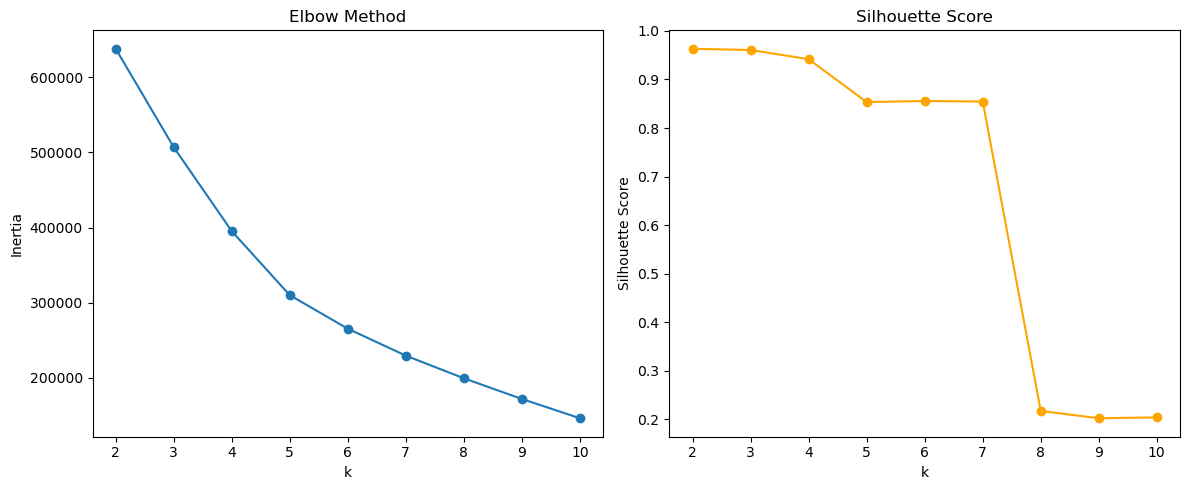

Optimal k (by silhouette): 2

3) APPLYING CLUSTERING (k=2)...

K-MEANS CLUSTERING

HIERARCHICAL CLUSTERING

DBSCAN CLUSTERING

KMEANS Evaluation:
Silhouette Score: 0.963
Davies-Bouldin Index: 0.504

HIERARCHICAL Evaluation:
Silhouette Score: 0.969
Davies-Bouldin Index: 0.313

DBSCAN found 12 clusters
Noise points: 7981

4) INTERPRETING CLUSTERS...

CLUSTER INTERPRETATIONS

CLUSTER 0 - 8935 customers (99.8%)
----------------------------------------
Type: Cash Advance Users
Description: Sering menggunakan cash advance, indikasi tekanan finansial.

Key Statistics (mean):
 • Balance: 1,393
 • Purchases: 737
 • Cash Advances: 674
 • Credit Limit: 4,421
 • Payments: 1,348

Derived Metrics:
 • Credit Utilization: 31.5%
 • Purchase to Balance Ratio: 0.53

CLUSTER 1 - 15 customers (0.2%)
----------------------------------------
Type: High Spenders / Good Payer
Description: Sering belanja tapi balance rendah, cenderung bayar penuh.

Key Statistics (mean):
 • Balance: 0
 • Purchases: 1,078
 • Cas

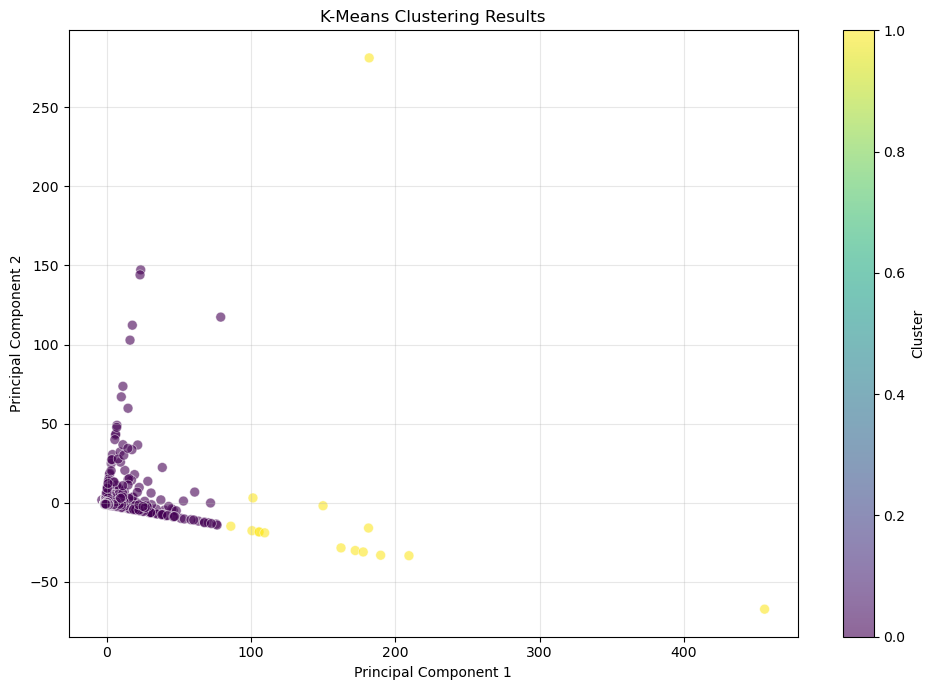


Cluster distribution for K-Means:
Cluster 0: 8935 customers (99.8%)
Cluster 1: 15 customers (0.2%)


In [10]:
def customer_clustering_pipeline(filepath):
    print("="*60)
    print("CUSTOMER CLUSTERING PIPELINE")
    print("="*60)

    print("\n1) LOADING & PREPROCESSING...")
    df = pd.read_csv(filepath)
    scaled_data, df_clean, cust_ids, scaler = preprocess_data(df)

    print("\n2) FINDING OPTIMAL K...")
    optimal_k = find_optimal_clusters(scaled_data)

    print(f"\n3) APPLYING CLUSTERING (k={optimal_k})...")
    results = apply_clustering(scaled_data, n_clusters=optimal_k)

    print("\n4) INTERPRETING CLUSTERS...")
    df_labeled, profiles = interpret_clusters(
        df_clean,
        results['kmeans']['labels'],
        optimal_k
    )

    visualize_clusters(scaled_data, results['kmeans']['labels'], 'K-Means')

    return {
        'data': df_labeled,
        'scaled_data': scaled_data,
        'profiles': profiles,
        'model': results['kmeans']['model'],
        'labels': results['kmeans']['labels']
    }


pipeline_results = customer_clustering_pipeline('clusteringmidterm.csv')
